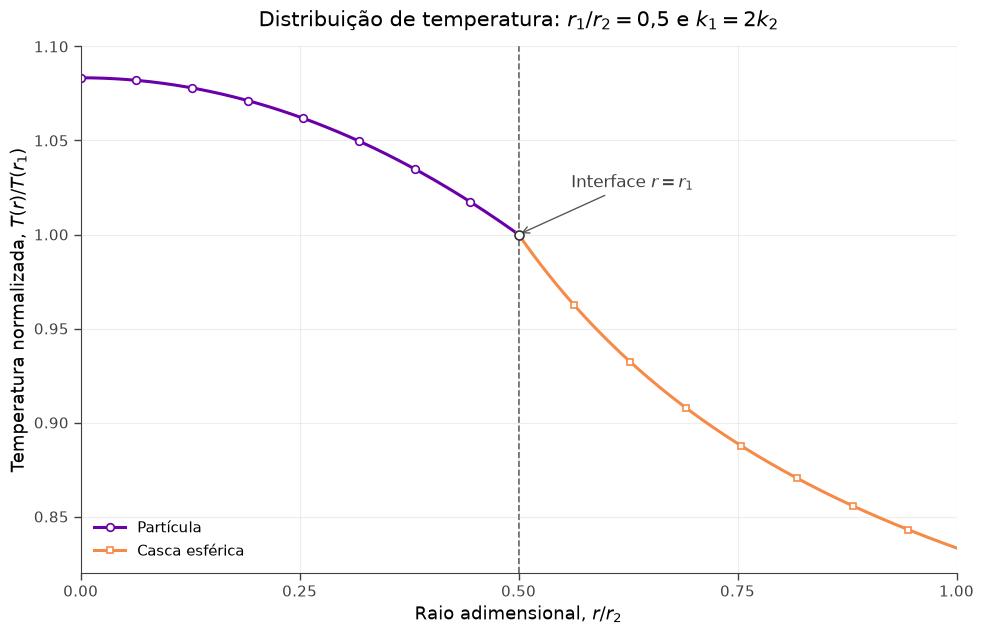

T(0)/T(r1)  = 1.0833
T(r1)/T(r1) = 1.0000
T(r2)/T(r1) = 0.8333


In [ ]:
import numpy as np
import matplotlib.pyplot as plt


# EXERCICIO 2.63 - PARTICULA ESFERICA COM GERACAO DE CALOR
# O enunciado nao fornece valores numericos. Os valores abaixo sao
# ilustrativos e foram escolhidos para reproduzir a curva qualitativa
# apresentada no solucionario.

# Geometria
r2 = 1.0
r1 = 0.5 * r2

# Propriedades e condicoes de contorno
k2 = 1.0
k1 = 2.0 * k2          # relacao dada no enunciado
q_dot = 1.0             # geracao volumetrica uniforme
h = 0.20 * k2 / r2      # Bi = h*r2/k2 = 0,20
T_inf = 0.0

# Malhas radiais suaves
r_particula = np.linspace(0.0, r1, 300)
r_casca = np.linspace(r1, r2, 300)

# Temperatura na superficie externa r = r2, obtida pela conveccao:
# q_dot*(4*pi*r1**3/3) = h*(4*pi*r2**2)*(T_r2 - T_inf)
T_r2 = T_inf + q_dot * r1**3 / (3.0 * h * r2**2)

# Perfil de temperatura na casca: r1 <= r <= r2
T_casca = (
    T_r2
    + q_dot * r1**3 / (3.0 * k2)
    * (1.0 / r_casca - 1.0 / r2)
)

# Continuidade da temperatura na interface r = r1
T_r1 = T_casca[0]

# Perfil de temperatura na particula: 0 <= r <= r1
T_particula = T_r1 + q_dot * (r1**2 - r_particula**2) / (6.0 * k1)

# Normalizacao adotada pelo solucionario
theta_particula = T_particula / T_r1
theta_casca = T_casca / T_r1


# GRAFICO
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 15,
    "axes.labelsize": 13,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "mathtext.fontset": "dejavusans",
})

fig, ax = plt.subplots(figsize=(10, 6.5))

cor_particula = plt.cm.plasma(0.20)
cor_casca = plt.cm.plasma(0.72)

ax.plot(
    r_particula / r2,
    theta_particula,
    color=cor_particula,
    linewidth=2.2,
    marker="o",
    markevery=38,
    markersize=5.5,
    markerfacecolor="white",
    markeredgewidth=1.2,
    label="Partícula",
)

ax.plot(
    r_casca / r2,
    theta_casca,
    color=cor_casca,
    linewidth=2.2,
    marker="s",
    markevery=38,
    markersize=5.0,
    markerfacecolor="white",
    markeredgewidth=1.2,
    label="Casca esférica",
)

# Linha da interface entre os materiais
ax.axvline(
    r1 / r2,
    color="0.35",
    linestyle="--",
    linewidth=1.2,
    zorder=0,
)

ax.scatter(
    r1 / r2,
    1.0,
    s=42,
    color="white",
    edgecolor="0.20",
    linewidth=1.2,
    zorder=5,
)

ax.annotate(
    r"Interface $r=r_1$",
    xy=(r1 / r2, 1.0),
    xytext=(0.56, 1.025),
    arrowprops=dict(arrowstyle="->", color="0.35", lw=1.0),
    color="0.25",
)

# Eixos e titulo
ax.set_xlabel(r"Raio adimensional, $r/r_2$")
ax.set_ylabel(r"Temperatura normalizada, $T(r)/T(r_1)$")
ax.set_title(
    r"Distribuição de temperatura: $r_1/r_2=0{,}5$ e $k_1=2k_2$",
    pad=14,
)

ax.set_xticks([0.00, 0.25, 0.50, 0.75, 1.00])
ax.set_yticks([0.85, 0.90, 0.95, 1.00, 1.05, 1.10])
ax.set_xlim(0.0, 1.0)
ax.set_ylim(0.82, 1.10)

ax.grid(True, which="major", color="0.75", linewidth=0.8, alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("0.25")
ax.spines["bottom"].set_color("0.25")
ax.tick_params(direction="out", length=5, width=1, colors="0.25")
ax.legend(frameon=False, loc="lower left")

fig.tight_layout()

fig.savefig("grafico_exercicio_2_63.png", dpi=600, bbox_inches="tight")
fig.savefig("grafico_exercicio_2_63.pdf", bbox_inches="tight")

plt.show()


print(f"T(0)/T(r1)  = {theta_particula[0]:.4f}")
print(f"T(r1)/T(r1) = {theta_particula[-1]:.4f}")
print(f"T(r2)/T(r1) = {theta_casca[-1]:.4f}")


## 3.154


CONFIGURACAO ORIGINAL
m                 = 81.650 1/m
mL                = 1.960
eta_f             = 0.490
A_f'              = 0.0480 m
A_t'              = 0.4605 m
eta_o             = 0.575
R_conv,i'         = 2.449 x 10^-3 m.K/W
R_cond'           = 1.652 x 10^-3 m.K/W
R_t,e'            = 18.878 x 10^-3 m.K/W
q'                = 2828.7 W/m


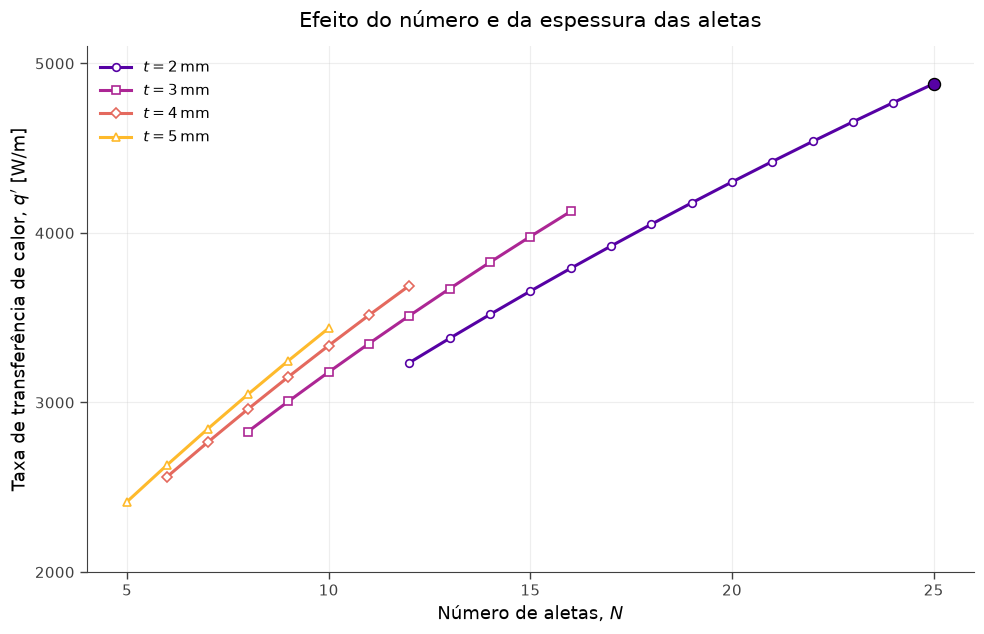


MELHOR CONFIGURACAO ANALISADA
N                 = 25
t                 = 2 mm
N*t               = 50 mm
q'                = 4880.0 W/m


In [ ]:
import numpy as np
import matplotlib.pyplot as plt



# EXERCICIO 3.154 - AQUECEDOR DE AR COM ALETAS LONGITUDINAIS
# Analise por unidade de comprimento axial do tubo


# Geometria e propriedades no SI
k = 20.0                 # W/(m.K)
r1 = 13e-3               # m
r2 = 16e-3               # m
r3 = 40e-3               # m
hi = 5000.0              # W/(m2.K)
he = 200.0               # W/(m2.K)
T_inf_i = 90.0           # graus Celsius
T_inf_e = 25.0           # graus Celsius

# Comprimento da aleta na direcao radial
L = r3 - r2

# Resistencias que nao dependem do arranjo de aletas
R_conv_i = 1.0 / (hi * 2.0 * np.pi * r1)
R_cond = np.log(r2 / r1) / (2.0 * np.pi * k)


def desempenho_aletas(N, t):
    """Calcula eficiencias, resistencia externa e calor por metro.

    Parametros
    ----------
    N : int
        Numero de aletas.
    t : float
        Espessura de cada aleta em metros.
    """
    # Aleta longitudinal reta, secao retangular e ponta adiabatica
    m = np.sqrt(2.0 * he / (k * t))
    eta_f = np.tanh(m * L) / (m * L)

    # Area de uma aleta por unidade de comprimento: duas faces
    A_f = 2.0 * L

    # Area total exposta: aletas + base nao coberta por elas
    A_t = N * A_f + (2.0 * np.pi * r2 - N * t)

    # Eficiencia global da superficie aletada
    eta_o = 1.0 - (N * A_f / A_t) * (1.0 - eta_f)

    # Resistencia equivalente da superficie externa aletada
    R_t_e = 1.0 / (eta_o * he * A_t)

    # Taxa de transferencia de calor por unidade de comprimento
    q_linha = (T_inf_i - T_inf_e) / (R_conv_i + R_cond + R_t_e)

    return m, eta_f, A_f, A_t, eta_o, R_t_e, q_linha


# ITEM (b): CONFIGURACAO ORIGINAL - N = 8 E t = 3 mm
N_original = 8
t_original = 3e-3

m, eta_f, A_f, A_t, eta_o, R_t_e, q_original = desempenho_aletas(
    N_original, t_original
)

print("CONFIGURACAO ORIGINAL")
print(f"m                 = {m:.3f} 1/m")
print(f"mL                = {m * L:.3f}")
print(f"eta_f             = {eta_f:.3f}")
print(f"A_f'              = {A_f:.4f} m")
print(f"A_t'              = {A_t:.4f} m")
print(f"eta_o             = {eta_o:.3f}")
print(f"R_conv,i'         = {R_conv_i * 1e3:.3f} x 10^-3 m.K/W")
print(f"R_cond'           = {R_cond * 1e3:.3f} x 10^-3 m.K/W")
print(f"R_t,e'            = {R_t_e * 1e3:.3f} x 10^-3 m.K/W")
print(f"q'                = {q_original:.1f} W/m")


# ITEM (c): VARIACAO DO NUMERO E DA ESPESSURA DAS ALETAS
# Restricao: N*t <= 50 mm
casos = {
    2: np.arange(12, 26),
    3: np.arange(8, 17),
    4: np.arange(6, 13),
    5: np.arange(5, 11),
}

resultados = {}

for t_mm, numeros_aletas in casos.items():
    t = t_mm * 1e-3
    taxas = []

    for N in numeros_aletas:
        # Todos os casos abaixo obedecem a N*t <= 50 mm
        *_, q_linha = desempenho_aletas(N, t)
        taxas.append(q_linha)

    resultados[t_mm] = np.array(taxas)


# GRAFICO
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 15,
    "axes.labelsize": 13,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "mathtext.fontset": "dejavusans",
})

fig, ax = plt.subplots(figsize=(10, 6.5))

cores = plt.cm.plasma(np.linspace(0.15, 0.85, len(casos)))
marcadores = ["o", "s", "D", "^"]

for cor, marcador, (t_mm, numeros_aletas) in zip(
    cores, marcadores, casos.items()
):
    ax.plot(
        numeros_aletas,
        resultados[t_mm],
        color=cor,
        linewidth=2.2,
        marker=marcador,
        markersize=5.5,
        markerfacecolor="white",
        markeredgewidth=1.2,
        label=rf"$t={t_mm}\,\mathrm{{mm}}$",
    )

# Destaca a melhor configuracao admissivel
N_otimo = 25
t_otimo_mm = 2
q_otimo = resultados[t_otimo_mm][-1]

ax.scatter(
    N_otimo,
    q_otimo,
    s=75,
    color=cores[0],
    edgecolor="black",
    linewidth=1.0,
    zorder=5,
)

ax.set_xlabel(r"Número de aletas, $N$")
ax.set_ylabel(r"Taxa de transferência de calor, $q'$ [W/m]")
ax.set_title("Efeito do número e da espessura das aletas", pad=14)

ax.set_xlim(4, 26)
ax.set_ylim(2000, 5100)
ax.set_xticks([5, 10, 15, 20, 25])
ax.set_yticks([2000, 3000, 4000, 5000])

ax.grid(True, color="0.75", linewidth=0.8, alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("0.25")
ax.spines["bottom"].set_color("0.25")
ax.tick_params(direction="out", length=5, width=1, colors="0.25")
ax.legend(frameon=False, loc="upper left")

fig.tight_layout()
fig.savefig("grafico_exercicio_3_154.png", dpi=600, bbox_inches="tight")
fig.savefig("grafico_exercicio_3_154.pdf", bbox_inches="tight")
plt.show()

print("\nMELHOR CONFIGURACAO ANALISADA")
print(f"N                 = {N_otimo}")
print(f"t                 = {t_otimo_mm} mm")
print(f"N*t               = {N_otimo * t_otimo_mm} mm")
print(f"q'                = {q_otimo:.1f} W/m")
